In [1]:
import h5py
import json
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Set up paths - look for recorded data in the dataset directory (rosbag subdirectories)
recorded_data_dir = Path("/home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data")
print(f"Looking for recorded data in: {recorded_data_dir}")
print(f"Directory exists: {recorded_data_dir.exists()}")

# Recursively search for HDF5 files in rosbag directories (sorted by modification time, newest first)
print("\nSearching for HDF5 files in rosbag directories...")
h5_files = sorted(recorded_data_dir.glob("**/*.h5"), key=lambda p: p.stat().st_mtime, reverse=True)

if h5_files:
    print(f"\nFound {len(h5_files)} HDF5 files:")
    for f in h5_files[:10]:  # Show first 10
        size_mb = f.stat().st_size / (1024*1024)
        print(f"  {f.parent.name}/{f.name} ({size_mb:.2f} MB)")
else:
    print("\n⚠ No HDF5 files found")

# Get the most recent recording
last_episode = h5_files[0] if h5_files else None
if last_episode:
    print(f"\n✓ Latest recording: {last_episode.parent.name}/{last_episode.name}")

Looking for recorded data in: /home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data
Directory exists: True

Searching for HDF5 files in rosbag directories...

Found 1 HDF5 files:
  recorded_data/spot_bag_20260309_142640_beginner_med_converted.h5 (0.50 MB)

✓ Latest recording: recorded_data/spot_bag_20260309_142640_beginner_med_converted.h5


## Load and Inspect Episode Data

Let's examine the structure of the recorded episodes.

In [2]:
# Load the most recent episode (already found in previous cell)
if last_episode:
    print(f"Loading: {last_episode.parent.name}/{last_episode.name}")
    
    with h5py.File(last_episode, 'r') as f:
        print("\nData structure:")
        print(f"  Top-level keys: {list(f.keys())}")
        
        # Print detailed structure
        def print_structure(name, obj):
            indent = "    " * (name.count('/') + 1)
            if isinstance(obj, h5py.Dataset):
                print(
                    f"{indent}{name}: shape={obj.shape}, dtype={obj.dtype}, "
                    f"min={obj[()].min():.2f}, max={obj[()].max():.2f}"
                )
            else:
                print(f"{indent}{name}/ (Group)")
        
        f.visititems(print_structure)
        
        # Load data that exists
        velocities = None
        velocity_paths = [
            'observations/velocities',
            'observations/velocity',
            'observations/odometry',
            'observations/state',
            'states/velocities',
            'states/velocity',
            'states',
        ]
        for path in velocity_paths:
            if path in f:
                velocities = f[path][:]
                print(f"\n✓ Found velocities at: {path}")
                break
        
        # Fallback: search within observations for any key containing 'vel'
        if velocities is None and 'observations' in f:
            for key in f['observations'].keys():
                if 'vel' in key.lower():
                    velocities = f[f'observations/{key}'][:]
                    print(f"\n✓ Found velocities at: observations/{key}")
                    break
        
        # Load actions/timestamps if available
        actions = f['actions'][:] if 'actions' in f else None
        timestamps = f['timestamps'][:] if 'timestamps' in f else None

        # Load odometry states (position + orientation) if available
        states = f['observations/state'][:] if 'observations/state' in f else None
        if states is not None:
            print("\n✓ Found odometry states (position + orientation)")

        # Load locomotion modes if available
        locomotion_modes = f['observations/locomotion_mode'][:] if 'observations/locomotion_mode' in f else None
        if locomotion_modes is not None:
            print("\n✓ Found locomotion_modes")
        
        # Initialize variables
        images_front = None
        depth_left = None
        depth_right = None
        depth_registered_left = None
        depth_registered_right = None
        has_front_stitched = False

        # Stitched front camera only (no stereo fallback)
        if 'observations/images_front' in f:
            images_front = f['observations/images_front'][:]
            has_front_stitched = True
            print("\n✓ Found stitched front camera: observations/images_front")
        else:
            print("\n⚠ Stitched front camera not found: observations/images_front")

        # Registered depth only
        depth_registered_left = f['observations/depth_registered_left'][:] if 'observations/depth_registered_left' in f else None
        depth_registered_right = f['observations/depth_registered_right'][:] if 'observations/depth_registered_right' in f else None
        if depth_registered_left is not None or depth_registered_right is not None:
            print("✓ Found registered depth")
else:
    print("\n⚠ No HDF5 files found! Cannot load episode.")
    # Initialize variables as None to prevent NameError
    velocities = None
    actions = None
    timestamps = None
    states = None
    locomotion_modes = None
    images_front = None
    depth_registered_left = None
    depth_registered_right = None
    has_front_stitched = False

print("\nEpisode Summary:")
if timestamps is not None:
    print(f"  Duration: {timestamps[-1] - timestamps[0]:.2f} seconds")
    print(f"  Steps: {len(timestamps)}")
    if timestamps[-1] - timestamps[0] > 0:
        print(f"  Step frequency: {len(timestamps) / (timestamps[-1] - timestamps[0]):.2f} Hz")
else:
    print("  Timestamps not available")

if has_front_stitched:
    print("  Camera format: STITCHED")
    print(f"    Front Stitched Images: {images_front.shape} (virtual wide-angle)")
else:
    print("  Camera format: MISSING")

if depth_registered_left is not None:
    print(f"    Depth Left (registered): {depth_registered_left.shape}")
if depth_registered_right is not None:
    print(f"    Depth Right (registered): {depth_registered_right.shape}")
if depth_registered_left is None and depth_registered_right is None:
    print("    Depth (registered): Not recorded")

if actions is not None:
    print(f"  Actions: {actions.shape}")
else:
    print("  Actions: Not recorded")
    
if states is not None:
    print(f"  Odometry States (pos+orient): {states.shape}")
else:
    print("  Odometry States: Not recorded")

if locomotion_modes is not None:
    print(f"  Locomotion Modes: {locomotion_modes.shape}")
else:
    print("  Locomotion Modes: Not recorded")

Loading: recorded_data/spot_bag_20260309_142640_beginner_med_converted.h5

Data structure:
  Top-level keys: ['actions', 'observations', 'timestamps']
    actions: shape=(19, 4), dtype=float32, min=-1.00, max=1.00
    observations/ (Group)
        observations/collision_events: shape=(19,), dtype=bool, min=0.00, max=0.00
        observations/images_front: shape=(19, 49, 128, 3), dtype=uint8, min=0.00, max=255.00
        observations/locomotion_mode: shape=(19,), dtype=uint32, min=1.00, max=1.00
        observations/state: shape=(19, 7), dtype=float32, min=-2.04, max=2.81
        observations/terrain_grids: shape=(19, 64, 64), dtype=float32, min=0.00, max=19.91
        observations/velocities: shape=(19, 6), dtype=float32, min=-0.92, max=1.10
    timestamps: shape=(19,), dtype=float64, min=1773066401.83, max=1773066408.58

✓ Found velocities at: observations/velocities

✓ Found odometry states (position + orientation)

✓ Found locomotion_modes

✓ Found stitched front camera: observation

## Visualize Sample Observations

Using only the stitched front camera (`/camera/frontmiddle_virtual/image`) and registered depth.
No stereo RGB or raw depth is loaded anymore.

/tmp/ipykernel_581772/393960306.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


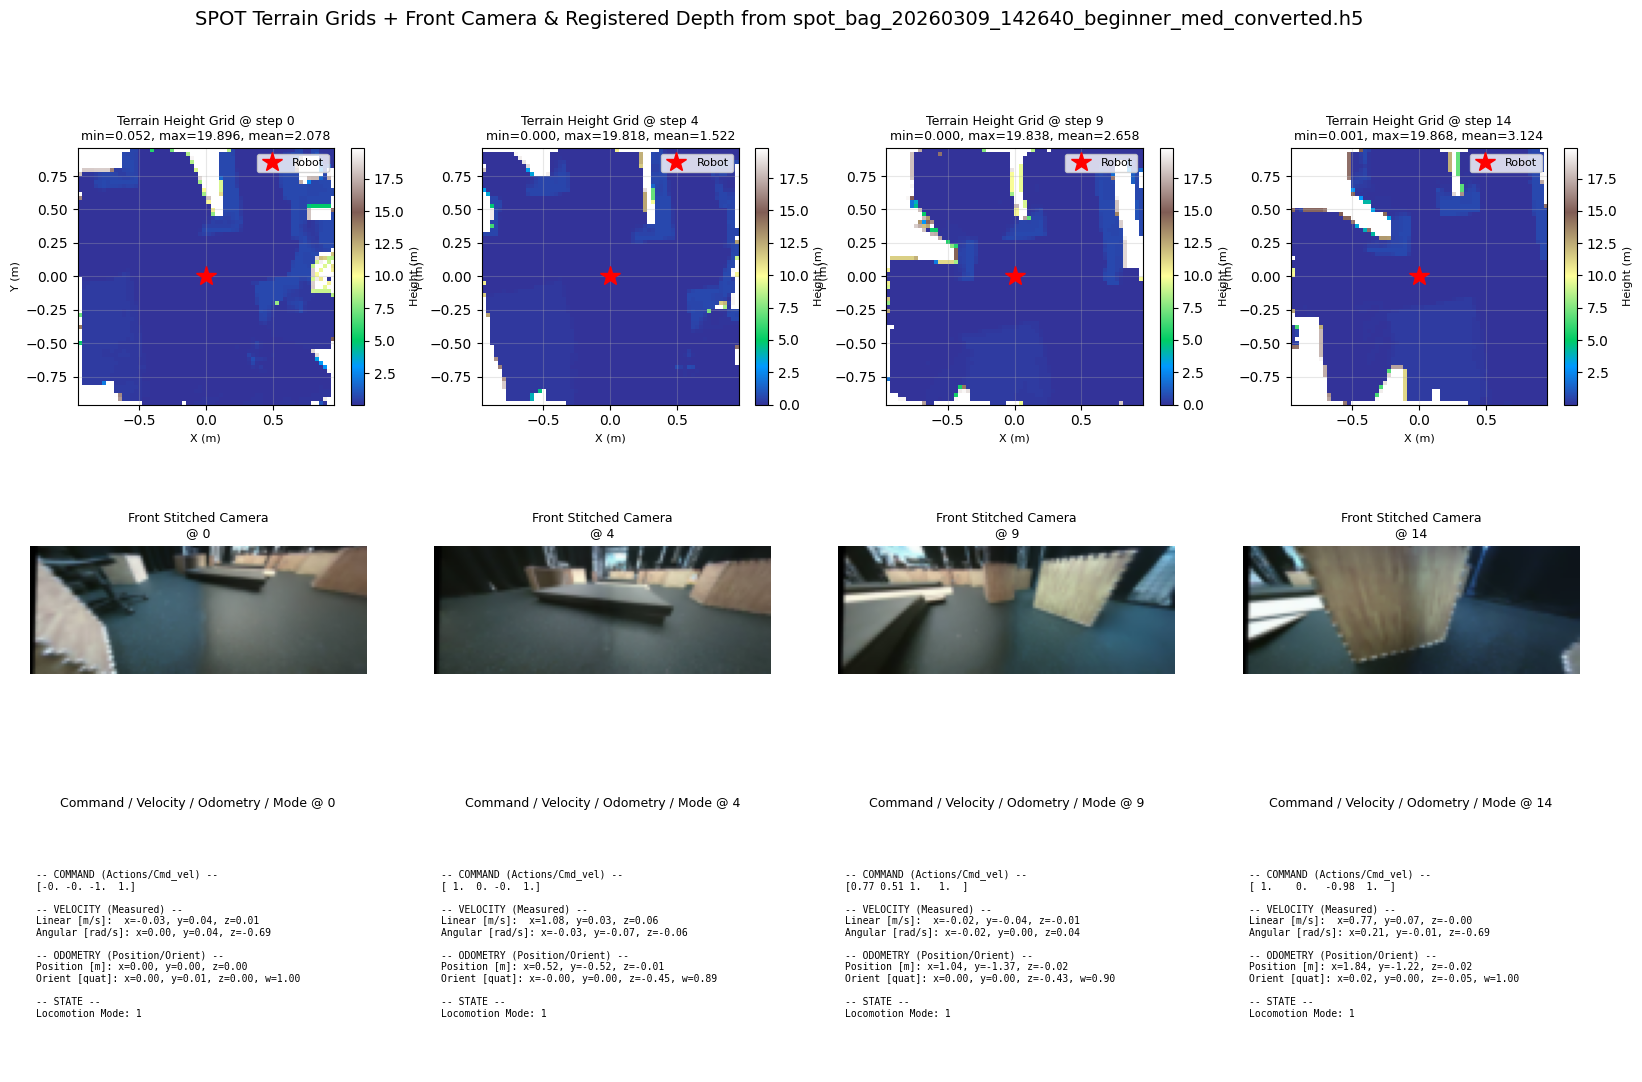

In [3]:
# Visualize terrain grids and camera data together
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom

# Load terrain grids if available
with h5py.File(last_episode, 'r') as f:
    has_terrain = 'observations/terrain_grids' in f
    if has_terrain:
        terrain_grids = f['observations/terrain_grids'][:]
        cell_size = f.attrs.get('terrain_grid_cell_size', 0.03)

# Prepare visualization parameters
has_reg_depth = depth_registered_left is not None or depth_registered_right is not None
has_vel = velocities is not None
has_states = states is not None
has_locomotion = locomotion_modes is not None
has_actions = actions is not None
has_front_stitched = images_front is not None

# Stitched image only (no stereo fallback)
image_data = images_front if has_front_stitched else None

# Calculate total rows
total_rows = 0
if has_terrain:
    total_rows += 1
if has_front_stitched:
    total_rows += 1
if has_reg_depth:
    total_rows += 1  # registered depth row
if has_vel or has_states or has_locomotion or has_actions:
    total_rows += 1  # text row
if total_rows == 0:
    total_rows = 1

# Create single large figure
fig = plt.figure(figsize=(20, 4 * total_rows))
gs = fig.add_gridspec(total_rows, 4, hspace=0.3, wspace=0.2)

# Choose indices from available data
def _first_len(*arrays):
    for arr in arrays:
        if arr is not None:
            return len(arr)
    return 0

num_samples = _first_len(image_data, depth_registered_left, depth_registered_right, velocities, states, actions)
if num_samples == 0:
    print("⚠ No samples found to visualize")
    plt.show()
else:
    indices = [0, num_samples // 4, num_samples // 2, 3 * num_samples // 4]

    current_row = 0

    # Row 0: Terrain grids if available
    if has_terrain:
        terrain_len = len(terrain_grids)
        terrain_indices = [0, terrain_len // 4, terrain_len // 2, 3 * terrain_len // 4]
        for idx, sample_idx in enumerate(terrain_indices):
            ax = fig.add_subplot(gs[current_row, idx])
            grid = terrain_grids[sample_idx]

            # Calculate world coordinates
            width = grid.shape[1] * cell_size
            height = grid.shape[0] * cell_size
            extent = [-width / 2, width / 2, -height / 2, height / 2]

            im = ax.imshow(grid, cmap='terrain', origin='lower', extent=extent)
            ax.plot(0, 0, 'r*', markersize=15, label='Robot')

            min_val = grid.min()
            max_val = grid.max()
            mean_val = grid.mean()

            ax.set_title(
                f'Terrain Height Grid @ step {sample_idx}\n'
                f'min={min_val:.3f}, max={max_val:.3f}, mean={mean_val:.3f}',
                fontsize=9,
            )
            ax.set_xlabel('X (m)', fontsize=8)
            ax.set_ylabel('Y (m)', fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize=8)

            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, fraction=0.046)
            cbar.set_label('Height (m)', fontsize=8)

        current_row += 1
    else:
        print("⚠ No terrain grids found in this episode")

    # Stitched front camera row
    if has_front_stitched:
        for idx, sample_idx in enumerate(indices):
            ax = fig.add_subplot(gs[current_row, idx])
            img_front = images_front[sample_idx]
            ax.imshow(img_front)
            ax.set_title(f'Front Stitched Camera\n@ {sample_idx}', fontsize=9)
            ax.axis('off')
        current_row += 1
    else:
        print("⚠ No stitched front camera found for visualization")

    # Registered depth row
    if has_reg_depth:
        for idx, sample_idx in enumerate(indices):
            ax = fig.add_subplot(gs[current_row, idx])
            if depth_registered_left is not None and depth_registered_right is not None:
                d_left = depth_registered_left[sample_idx]
                d_right = depth_registered_right[sample_idx]
                if d_left.shape != d_right.shape:
                    scale = (d_right.shape[0] / d_left.shape[0], d_right.shape[1] / d_left.shape[1])
                    d_left_resized = zoom(d_left.astype(np.float32), scale, order=1)
                    depth_reg = np.concatenate([d_left_resized, d_right], axis=1)
                else:
                    depth_reg = np.concatenate([d_left, d_right], axis=1)
                title = f'Registered Depth\n(L|R) @ {sample_idx}'
            elif depth_registered_left is not None:
                depth_reg = depth_registered_left[sample_idx]
                title = f'Registered Depth L\n@ {sample_idx}'
            else:
                depth_reg = depth_registered_right[sample_idx]
                title = f'Registered Depth R\n@ {sample_idx}'
            im = ax.imshow(depth_reg, cmap='viridis')
            ax.set_title(title, fontsize=9)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)
        current_row += 1

    # Row: Velocities, States, Actions and Locomotion Mode if available
    if has_vel or has_states or has_locomotion or has_actions:
        for idx, sample_idx in enumerate(indices):
            ax = fig.add_subplot(gs[current_row, idx])

            display_text = ""

            if has_actions:
                a = actions[sample_idx]
                # Expecting [vx, vy, vz, wx, wy, wz] or similar
                if a.shape[0] >= 6:
                    a_lin = a[:3]
                    a_ang = a[3:6]
                    act_text = (
                        f"Linear [m/s]:  x={a_lin[0]:.2f}, y={a_lin[1]:.2f}, z={a_lin[2]:.2f}\n"
                        f"Angular [rad/s]: x={a_ang[0]:.2f}, y={a_ang[1]:.2f}, z={a_ang[2]:.2f}"
                    )
                else:
                    act_text = f"{np.array2string(a, precision=2)}"
                display_text += f"-- COMMAND (Actions/Cmd_vel) --\n{act_text}\n\n"

            if has_vel:
                v = velocities[sample_idx]
                # Expecting [vx, vy, vz, wx, wy, wz] but handle any length safely
                if v.shape[0] >= 6:
                    v_lin = v[:3]
                    v_ang = v[3:6]
                    vel_text = (
                        f"Linear [m/s]:  x={v_lin[0]:.2f}, y={v_lin[1]:.2f}, z={v_lin[2]:.2f}\n"
                        f"Angular [rad/s]: x={v_ang[0]:.2f}, y={v_ang[1]:.2f}, z={v_ang[2]:.2f}"
                    )
                else:
                    vel_text = f"{np.array2string(v, precision=2)}"
                display_text += f"-- VELOCITY (Measured) --\n{vel_text}\n\n"

            if has_states:
                s = states[sample_idx]
                # Expecting [x, y, z, qx, qy, qz, qw]
                if s.shape[0] >= 7:
                    s_pos = s[:3]
                    s_quat = s[3:7]
                    state_text = (
                        f"Position [m]: x={s_pos[0]:.2f}, y={s_pos[1]:.2f}, z={s_pos[2]:.2f}\n"
                        f"Orient [quat]: x={s_quat[0]:.2f}, y={s_quat[1]:.2f}, z={s_quat[2]:.2f}, w={s_quat[3]:.2f}"
                    )
                else:
                    state_text = f"{np.array2string(s, precision=2)}"
                display_text += f"-- ODOMETRY (Position/Orient) --\n{state_text}\n\n"

            if has_locomotion:
                mode = locomotion_modes[sample_idx]
                loco_text = f"Locomotion Mode: {mode}"
                display_text += f"-- STATE --\n{loco_text}"

            ax.text(0.02, 0.5, display_text, fontsize=7, va='center', ha='left', family='monospace')

            title_parts = []
            if has_actions:
                title_parts.append("Command")
            if has_vel:
                title_parts.append("Velocity")
            if has_states:
                title_parts.append("Odometry")
            if has_locomotion:
                title_parts.append("Mode")
            ax.set_title(f"{' / '.join(title_parts)} @ {sample_idx}", fontsize=9)
            ax.axis('off')

        current_row += 1

# Set overall title
if has_terrain:
    fig.suptitle(
        f'SPOT Terrain Grids + Front Camera & Registered Depth from {last_episode.name}',
        fontsize=14,
        y=0.995,
    )
else:
    fig.suptitle(
        f'SPOT Front Camera & Registered Depth from {last_episode.name}',
        fontsize=14,
        y=0.995,
    )

plt.tight_layout()
plt.show()

## Estimate cmd_vel → odometry lag
We'll estimate the delay (in samples and seconds) between commanded velocity and measured odometry using cross-correlation on linear x.

Analyzing command vs raw odometry velocities...

--- Axis: Linear X (action_index 0, odom_index 0) ---
Lengths -> actions: 19, velocities: 19, timestamps: 19
Using fixed lag: 1 samples
MSE (unaligned): 0.200011
MSE (aligned, lag=1): 0.2038913071155548


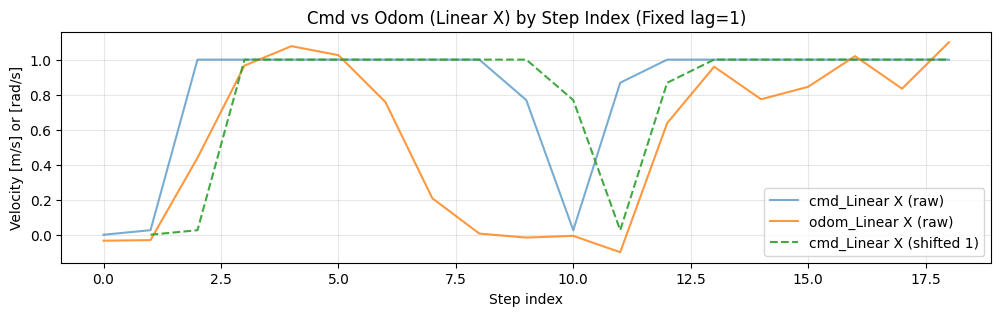


--- Axis: Linear Y (action_index 1, odom_index 1) ---
Lengths -> actions: 19, velocities: 19, timestamps: 19
Using fixed lag: 1 samples
MSE (unaligned): 0.023487
MSE (aligned, lag=1): 0.014150768518447876


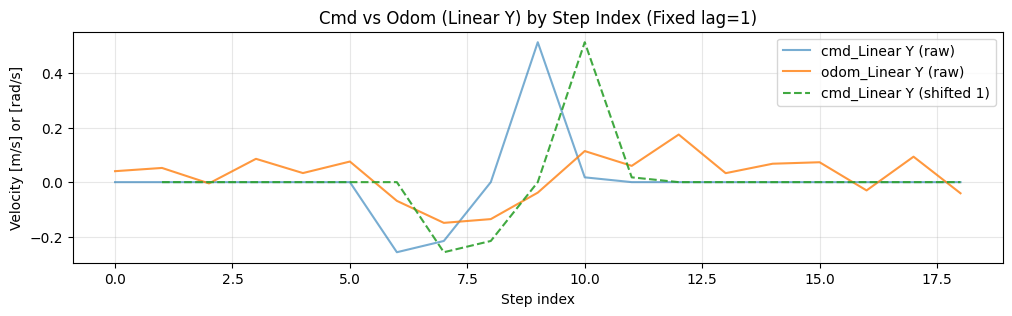


--- Axis: Angular Z (Yaw) (action_index 2, odom_index 5) ---
Lengths -> actions: 19, velocities: 19, timestamps: 19
Using fixed lag: 1 samples
MSE (unaligned): 0.233206
MSE (aligned, lag=1): 0.047500625252723694


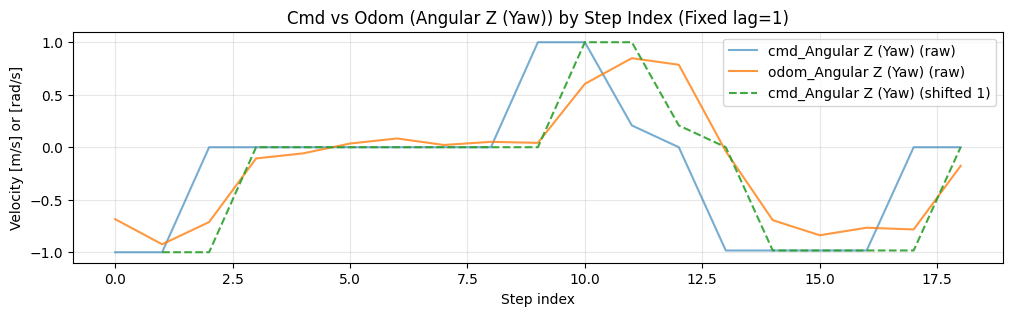

In [4]:
# Estimate lag between command (actions) and measured velocity (odometry)
# Use fixed known lag (1 sample) instead of estimating by cross-correlation.
import numpy as np
import matplotlib.pyplot as plt

FIXED_LAG = 1  # known fixed lag in samples (cmd -> odom)

if actions is None or velocities is None or timestamps is None:
    print("Missing actions, velocities, or timestamps for lag analysis.")
else:
    print("Analyzing command vs raw odometry velocities...")
    
    # Note: actions are [vx, vy, vyaw, gait_selection] (4D)
    # Note: velocities are raw as-is from odometry (6D: lin_x, lin_y, lin_z, ang_x, ang_y, ang_z)
    axes = [("Linear X", 0), ("Linear Y", 1), ("Angular Z (Yaw)", 2)]

    for name, axis_idx in axes:
        a_full = actions[:, axis_idx].astype(np.float32) if actions.shape[1] > axis_idx else np.zeros(len(actions), dtype=np.float32)
        # For yaw velocity comparison: use odom's angular.z (index 5)
        v_idx = 5 if axis_idx == 2 else axis_idx
        v_full = velocities[:, v_idx].astype(np.float32) if velocities.shape[1] > v_idx else np.zeros(len(velocities), dtype=np.float32)
        t_full = timestamps.astype(np.float32)

        print(f"\n--- Axis: {name} (action_index {axis_idx}, odom_index {v_idx}) ---")
        print(f"Lengths -> actions: {len(a_full)}, velocities: {len(v_full)}, timestamps: {len(t_full)}")

        T = min(len(a_full), len(v_full), len(t_full))
        if T == 0:
            print("  No samples available for this axis, skipping.")
            continue

        a = a_full[:T]
        v = v_full[:T]
        t = t_full[:T]

        lag_samples = int(FIXED_LAG)
        print(f"Using fixed lag: {lag_samples} samples")

        # MSE unaligned (direct sample-wise)
        try:
            mse_unaligned = np.mean((a - v) ** 2)
        except Exception:
            mse_unaligned = np.nan

        # Compute aligned MSE using fixed integer shift: odom[t] ~ cmd[t - lag]
        if 0 < lag_samples < len(a):
            a_for_v = a[:-lag_samples]
            v_for_a = v[lag_samples:]
            mse_aligned = np.mean((v_for_a - a_for_v) ** 2) if a_for_v.size and v_for_a.size else np.nan
        else:
            mse_aligned = np.nan

        print(f"MSE (unaligned): {mse_unaligned:.6f}")
        print(f"MSE (aligned, lag={lag_samples}): {mse_aligned if not np.isnan(mse_aligned) else 'n/a'}")

        # Plot full-length arrays and the shifted command (shift forward by lag to align with odom)
        max_len = max(len(a_full), len(v_full))
        idx_full = np.arange(max_len)
        a_plot = np.full(max_len, np.nan)
        v_plot = np.full(max_len, np.nan)
        a_plot[:len(a_full)] = a_full
        v_plot[:len(v_full)] = v_full

        a_shift_plot = np.full(max_len, np.nan)
        if lag_samples == 0:
            a_shift_plot[:len(a_full)] = a_full
        elif lag_samples > 0:
            # shifted_actions[t] = actions[t - lag] -> represent as moving the command forward
            n = max(0, len(a_full) - lag_samples)
            if n > 0:
                a_shift_plot[lag_samples:lag_samples + n] = a_full[:n]

        plt.figure(figsize=(12, 3))
        plt.plot(idx_full, a_plot, label=f'cmd_{name} (raw)', alpha=0.6)
        plt.plot(idx_full, v_plot, label=f'odom_{name} (raw)', alpha=0.8)
        plt.plot(idx_full, a_shift_plot, label=f'cmd_{name} (shifted {lag_samples})', alpha=0.9, linestyle='--')
        plt.title(f'Cmd vs Odom ({name}) by Step Index (Fixed lag={lag_samples})')
        plt.xlabel('Step index')
        plt.ylabel('Velocity [m/s] or [rad/s]')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()